# Лабораторная работа №3  Сравнение алгоритмов векторного поиска

###Задачи

1) Найти датасет
2) Выбрать случайных векторов-запросов из датасета (не менее 10к различных)
3) Для каждого вектора-запроса в исходном датасете при помощи kNN составить списки точных 100 соседей - их считаем ground truth
4) Выбрать любую библиотеку в которой уже есть готовые реализации LSH/HNSW/IVF+PQ
5) Для каждого алгоритма изучить настройки построения поискового индекса и в зависимости от различных настроек исследовать метрику полноты поиска Recall
6) Определить оптимальные параметры для каждого типа индекса
7) По критериям скорости индексации, размера поискового индекса, полноты поиска выбрать лучший.

**Датасет SIFT1M**

| Параметр | Значение |
|---|---:|
| Количество base-векторов | 1 000 000 |
| Количество query-векторов | 10 000 |
| Размерность вектора | 128 |
| Метрика расстояния | Euclidean / L2 |
| Ground truth | top-100 ближайших соседей |

**Алгоритмы**: LSH/HNSW/IVF+PQ

**Метрика**: Recall@100

Так как датасет использует **Euclidean / L2 distance**, нормализация векторов не требуется.

## **1.Загрузка датасета SIFT1M**

In [1]:
!pip install -q faiss-cpu h5py numpy pandas matplotlib tqdm huggingface_hub


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\Элина\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path
from urllib.request import urlretrieve

import os
import time
import h5py
import faiss
import numpy as np
import pandas as pd
import gc
import matplotlib.pyplot as plt

In [21]:
N_THREADS = 12 #os.cpu_count() 

faiss.omp_set_num_threads(N_THREADS)

print(f"FAISS threads: {faiss.omp_get_max_threads()}")

FAISS threads: 12


In [22]:
data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

dataset_path = data_dir / "sift-128-euclidean.hdf5"

dataset_url = (
    "https://huggingface.co/datasets/hhy3/ann-datasets/resolve/main/"
    "sift-128-euclidean.hdf5?download=true"
)

if not dataset_path.exists():
    urlretrieve(dataset_url, dataset_path)
    print(f"Готово: {dataset_path}")
else:
    print(f"Файл уже есть: {dataset_path}")

with h5py.File(dataset_path, "r") as file:
    print("\nКлючи:", list(file.keys()))

    for key in file.keys():
        print(key, file[key].shape, file[key].dtype)

    # query-векторы выбираются случайно из train
    # поэтому стандартные test/neighbors из файла дальше не используем.
    full_base_vectors = file["train"][:].astype("float32")

print("\nПолная база:", full_base_vectors.shape, full_base_vectors.dtype)

Файл уже есть: data\sift-128-euclidean.hdf5

Ключи: ['distances', 'neighbors', 'test', 'train']
distances (10000, 100) float32
neighbors (10000, 100) int32
test (10000, 128) float32
train (1000000, 128) float32

Полная база: (1000000, 128) float32


##**2. Подготовка данных**

выбираем случайно из полной базы 10 000 векторов, которые потом удаляем из корпуса поиска

In [23]:
# Общие настройки
RANDOM_STATE = 42
TOP_K = 100

N_QUERY_VECTORS = 10_000
SEARCH_BASE_SIZE = 500_000

rng = np.random.default_rng(RANDOM_STATE)
results = []

In [24]:
# выбираем случайные query-векторы из полной базы
query_indices = rng.choice(
    len(full_base_vectors),
    size=N_QUERY_VECTORS,
    replace=False
)

search_mask = np.ones(len(full_base_vectors), dtype=bool)
search_mask[query_indices] = False

query_vectors = full_base_vectors[query_indices].copy()
search_vectors = full_base_vectors[search_mask].copy()
search_original_indices = np.flatnonzero(search_mask).astype("int64")

# ограничиваем размер базы поиска для ускорения
if len(search_vectors) > SEARCH_BASE_SIZE:
    sampled_search_indices = rng.choice(
        len(search_vectors),
        size=SEARCH_BASE_SIZE,
        replace=False
    )

    search_vectors = search_vectors[sampled_search_indices].copy()

print("\nFinal search vectors:", search_vectors.shape)
print("Query vectors:", query_vectors.shape)


Final search vectors: (500000, 128)
Query vectors: (10000, 128)


## **3 Построение ground truth**

Ground truth строится с помощью точного kNN-поиска. Используем IndexFlatL2, который выполняет полный перебор по базе поиска и возвращает точные top-100 ближайших соседей для каждого query-вектора.
Полученный результат считаем правильными ответами и используем для recall@100

In [25]:
dim = search_vectors.shape[1]

index_exact = faiss.IndexFlatL2(dim)

t0 = time.perf_counter()
index_exact.add(search_vectors)
exact_build_time = time.perf_counter() - t0

t0 = time.perf_counter()
_, ground_truth = index_exact.search(query_vectors, TOP_K)
exact_search_time = time.perf_counter() - t0

print(f"Exact index build time: {exact_build_time:.2f} sec")
print(f"Exact kNN search time: {exact_search_time:.2f} sec")
print("Ground truth:", ground_truth.shape)

Exact index build time: 0.08 sec
Exact kNN search time: 8.13 sec
Ground truth: (10000, 100)


## **4 Выбор библиотеки + общие функции**

В качестве бибблиотеки была выбрана **FAISS**, так как именно в ней был реализован весь функционал по **LSH/HNSW/IVF+PQ**

In [26]:
def recall_at_k(predicted_neighbors, true_neighbors, k=100):
    recall_sum = 0.0

    for predicted, true in zip(predicted_neighbors[:, :k], true_neighbors[:, :k]):
        recall_sum += len(set(predicted) & set(true)) / k

    return recall_sum / len(true_neighbors)

In [27]:
#размер на диске
def get_index_size_mb(index, filename="temp_faiss_index.bin"):
    faiss.write_index(index, filename)
    size_mb = os.path.getsize(filename) / 1024 / 1024
    os.remove(filename)
    return size_mb

In [14]:
def save_result(
    results,
    algorithm,
    params,
    build_time_sec,
    search_time_sec,
    recall,
    index_size_mb,
    extra_params=None
):
    row = {
        "algorithm": algorithm,
        "params": params,
        "build_time_sec": build_time_sec,
        "search_time_sec": search_time_sec,
        "qps": len(query_vectors) / search_time_sec,
        "ms_per_query": 1000 * search_time_sec / len(query_vectors),
        "recall@100": recall,
        "index_size_mb": index_size_mb
    }

    if extra_params is not None:
        row.update(extra_params)

    results.append(row)
    return row

In [28]:
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 9


def annotate_best_point(ax, df, x_col, y_col, label_col="params"):
    best_idx = df["recall@100"].idxmax()
    best = df.loc[best_idx]

    ax.annotate(
        "best\n" + str(best[label_col]),
        (best[x_col], best[y_col]),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=7
    )


def normalize_sizes(series, min_size=30, max_size=160):
    if series.max() == series.min():
        return np.full(len(series), (min_size + max_size) / 2)

    return min_size + (max_size - min_size) * (
        (series - series.min()) / (series.max() - series.min())
    )

## **5. Исследование по каждому алгоритму**

### **5.1 LSH**
Основной исследуемый параметр nbits (к-во бит в бин хэше)

In [29]:
lsh_nbits_values = [128, 256, 512, 1024, 2048]

lsh_results = []

for nbits in lsh_nbits_values:
    index_lsh = faiss.IndexLSH(dim, nbits)

    t0 = time.perf_counter()
    index_lsh.add(search_vectors)
    build_time_sec = time.perf_counter() - t0

    t0 = time.perf_counter()
    _, predicted_neighbors = index_lsh.search(query_vectors, TOP_K)
    search_time_sec = time.perf_counter() - t0

    recall = recall_at_k(
        predicted_neighbors=predicted_neighbors,
        true_neighbors=ground_truth,
        k=TOP_K
    )

    index_size_mb = get_index_size_mb(index_lsh)

    row = save_result(
        results=results,
        algorithm="LSH",
        params=f"nbits={nbits}",
        build_time_sec=build_time_sec,
        search_time_sec=search_time_sec,
        recall=recall,
        index_size_mb=index_size_mb,
        extra_params={
            "nbits": nbits
        }
    )

    lsh_results.append(row)

    del index_lsh, predicted_neighbors
    gc.collect()

In [30]:
lsh_results_df = pd.DataFrame(lsh_results)

lsh_results_df = lsh_results_df.sort_values(
    by=["recall@100"],
    ascending=[False]
).reset_index(drop=True)

lsh_results_df

,algorithm,params,build_time_sec,search_time_sec,qps,ms_per_query,recall@100,index_size_mb,nbits
0,LSH,nbits=2048,1.237108,10.475676,954.592306,1.047568,0.715765,123.070401,2048
1,LSH,nbits=1024,0.577918,5.176593,1931.772388,0.517659,0.612506,61.535245,1024
2,LSH,nbits=512,0.304869,1.821540,5489.859023,0.182154,0.486139,30.767667,512
3,LSH,nbits=256,0.148635,1.015036,9851.867323,0.101504,0.339661,15.383878,256
4,LSH,nbits=128,0.099590,0.686193,14573.159446,0.068619,0.214604,7.691983,128


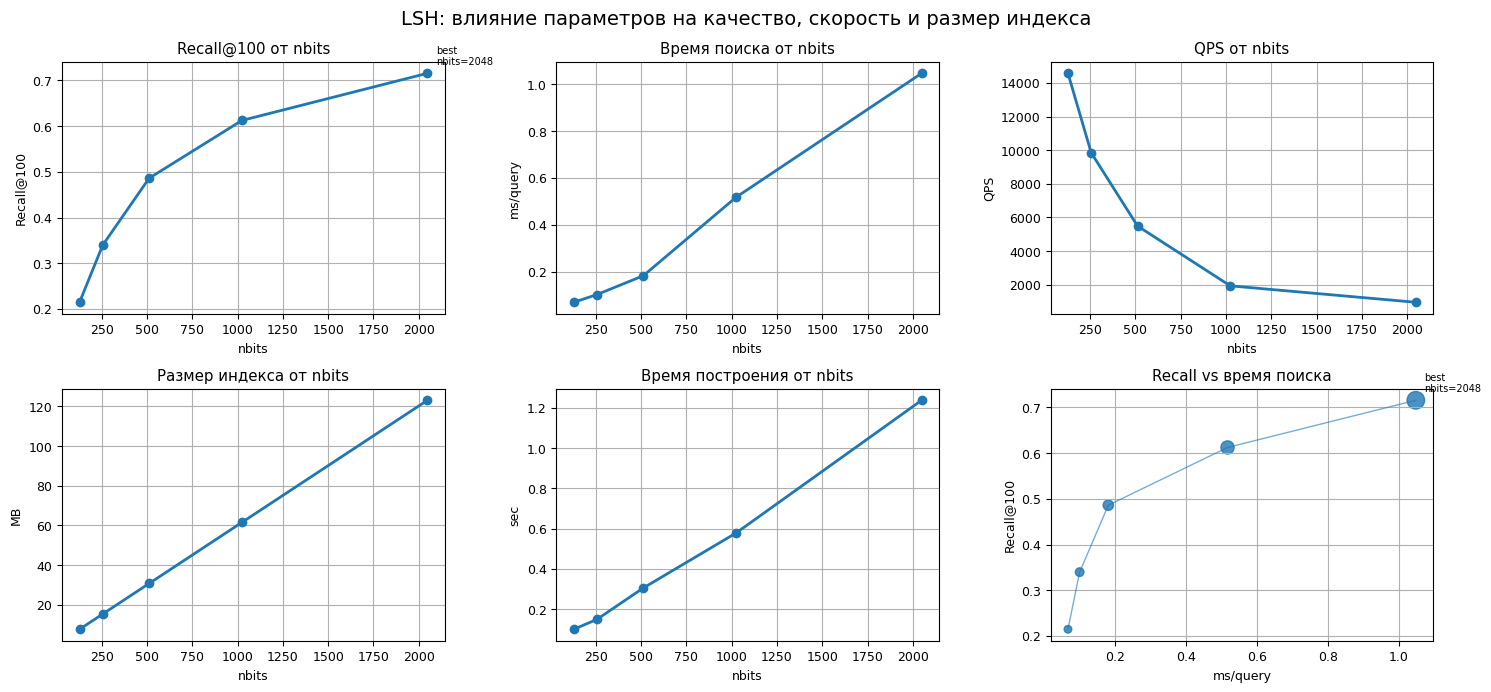

In [31]:
lsh_plot_df = lsh_results_df.sort_values("nbits").copy()

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()

# 1. Recall от nbits
axes[0].plot(
    lsh_plot_df["nbits"],
    lsh_plot_df["recall@100"],
    marker="o",
    linewidth=2
)
axes[0].set_title("Recall@100 от nbits")
axes[0].set_xlabel("nbits")
axes[0].set_ylabel("Recall@100")
annotate_best_point(axes[0], lsh_plot_df, "nbits", "recall@100")

# 2. ms_per_query от nbits
axes[1].plot(
    lsh_plot_df["nbits"],
    lsh_plot_df["ms_per_query"],
    marker="o",
    linewidth=2
)
axes[1].set_title("Время поиска от nbits")
axes[1].set_xlabel("nbits")
axes[1].set_ylabel("ms/query")

# 3. QPS от nbits
axes[2].plot(
    lsh_plot_df["nbits"],
    lsh_plot_df["qps"],
    marker="o",
    linewidth=2
)
axes[2].set_title("QPS от nbits")
axes[2].set_xlabel("nbits")
axes[2].set_ylabel("QPS")

# 4. Размер индекса от nbits
axes[3].plot(
    lsh_plot_df["nbits"],
    lsh_plot_df["index_size_mb"],
    marker="o",
    linewidth=2
)
axes[3].set_title("Размер индекса от nbits")
axes[3].set_xlabel("nbits")
axes[3].set_ylabel("MB")

# 5. Build time от nbits
axes[4].plot(
    lsh_plot_df["nbits"],
    lsh_plot_df["build_time_sec"],
    marker="o",
    linewidth=2
)
axes[4].set_title("Время построения от nbits")
axes[4].set_xlabel("nbits")
axes[4].set_ylabel("sec")

# 6. Recall vs время поиска
sizes = normalize_sizes(lsh_plot_df["index_size_mb"])

axes[5].scatter(
    lsh_plot_df["ms_per_query"],
    lsh_plot_df["recall@100"],
    s=sizes,
    alpha=0.8
)
axes[5].plot(
    lsh_plot_df["ms_per_query"],
    lsh_plot_df["recall@100"],
    linewidth=1,
    alpha=0.6
)
axes[5].set_title("Recall vs время поиска")
axes[5].set_xlabel("ms/query")
axes[5].set_ylabel("Recall@100")
annotate_best_point(axes[5], lsh_plot_df, "ms_per_query", "recall@100")

fig.suptitle("LSH: влияние параметров на качество, скорость и размер индекса", fontsize=14)
plt.tight_layout()
plt.show()

при увеличении `nbits` растет полнота поиска `Recall@100`, также размер индекса `index_size_mb` и время поиска `ms_per_query`. `QPS` снизился.

Интересно заметить, что для 128 и 256 параметры улучшились (search_time_sec	qps	ms_per_query), разница небольшая и может быть связана с тем, что в IndexLSH стоимость поиска не определяется только длиной хеша, но и завиит от преобразования запросов, сравнения бинарных кодов и внутренних блочных оптимизаций FAISS.

Для LSH оптимальным по качеству оказался параметр `nbits=2048`

### **5.2 HNSW**

Основной исследуемый параметры
`M` (к-во связей у вершины графа), `efSearch` (глубина поиска), `efConstruction ` (глубина построения графа)

In [56]:
hnsw_m_values = [16, 32]
hnsw_ef_construction_values = [100, 200]
hnsw_ef_search_values = [32, 64, 128]

hnsw_results = []

for m in hnsw_m_values:
    for ef_construction in hnsw_ef_construction_values:
        index_hnsw = faiss.IndexHNSWFlat(dim, m)
        index_hnsw.hnsw.efConstruction = ef_construction

        t0 = time.perf_counter()
        index_hnsw.add(search_vectors)
        build_time_sec = time.perf_counter() - t0

        index_size_mb = get_index_size_mb(index_hnsw)

        for ef_search in hnsw_ef_search_values:
            index_hnsw.hnsw.efSearch = ef_search

            t0 = time.perf_counter()
            _, predicted_neighbors = index_hnsw.search(query_vectors, TOP_K)
            search_time_sec = time.perf_counter() - t0

            recall = recall_at_k(
                predicted_neighbors=predicted_neighbors,
                true_neighbors=ground_truth,
                k=TOP_K
            )

            row = save_result(
                results=results,
                algorithm="HNSW",
                params=f"M={m}, efConstruction={ef_construction}, efSearch={ef_search}",
                build_time_sec=build_time_sec,
                search_time_sec=search_time_sec,
                recall=recall,
                index_size_mb=index_size_mb,
                extra_params={
                    "M": m,
                    "efConstruction": ef_construction,
                    "efSearch": ef_search
                }
            )

            hnsw_results.append(row)

            del predicted_neighbors
            gc.collect()

        del index_hnsw
        gc.collect()

In [71]:
hnsw_results_df = pd.DataFrame(hnsw_results)

hnsw_results_df = hnsw_results_df.sort_values(
    by=["recall@100"],
    ascending=[False]
).reset_index(drop=True)

hnsw_results_df.head(10)

,algorithm,params,build_time_sec,search_time_sec,qps,ms_per_query,recall@100,index_size_mb,M,efConstruction,efSearch
0,HNSW,"M=32, efConstruction=200, efSearch=128",76.085856,1.160516,8616.859610,0.116052,0.981110,373.903292,32,200,128
1,HNSW,"M=32, efConstruction=100, efSearch=128",35.865113,1.023588,9769.553811,0.102359,0.970021,373.903292,32,100,128
2,HNSW,"M=16, efConstruction=200, efSearch=128",57.621684,0.854942,11696.698525,0.085494,0.965406,312.939203,16,200,128
3,HNSW,"M=16, efConstruction=100, efSearch=128",30.200622,0.751297,13310.315361,0.075130,0.955344,312.939203,16,100,128
4,HNSW,"M=32, efConstruction=200, efSearch=64",76.085856,0.621502,16090.063163,0.062150,0.930012,373.903292,32,200,64
5,HNSW,"M=32, efConstruction=100, efSearch=64",35.865113,0.636704,15705.897643,0.063670,0.908286,373.903292,32,100,64
6,HNSW,"M=16, efConstruction=200, efSearch=64",57.621684,0.507973,19686.093429,0.050797,0.891709,312.939203,16,200,64
7,HNSW,"M=16, efConstruction=100, efSearch=64",30.200622,0.460572,21712.122443,0.046057,0.876197,312.939203,16,100,64
8,HNSW,"M=32, efConstruction=200, efSearch=32",76.085856,0.381652,26201.893978,0.038165,0.817593,373.903292,32,200,32
9,HNSW,"M=32, efConstruction=100, efSearch=32",35.865113,0.334817,29867.061708,0.033482,0.788282,373.903292,32,100,32


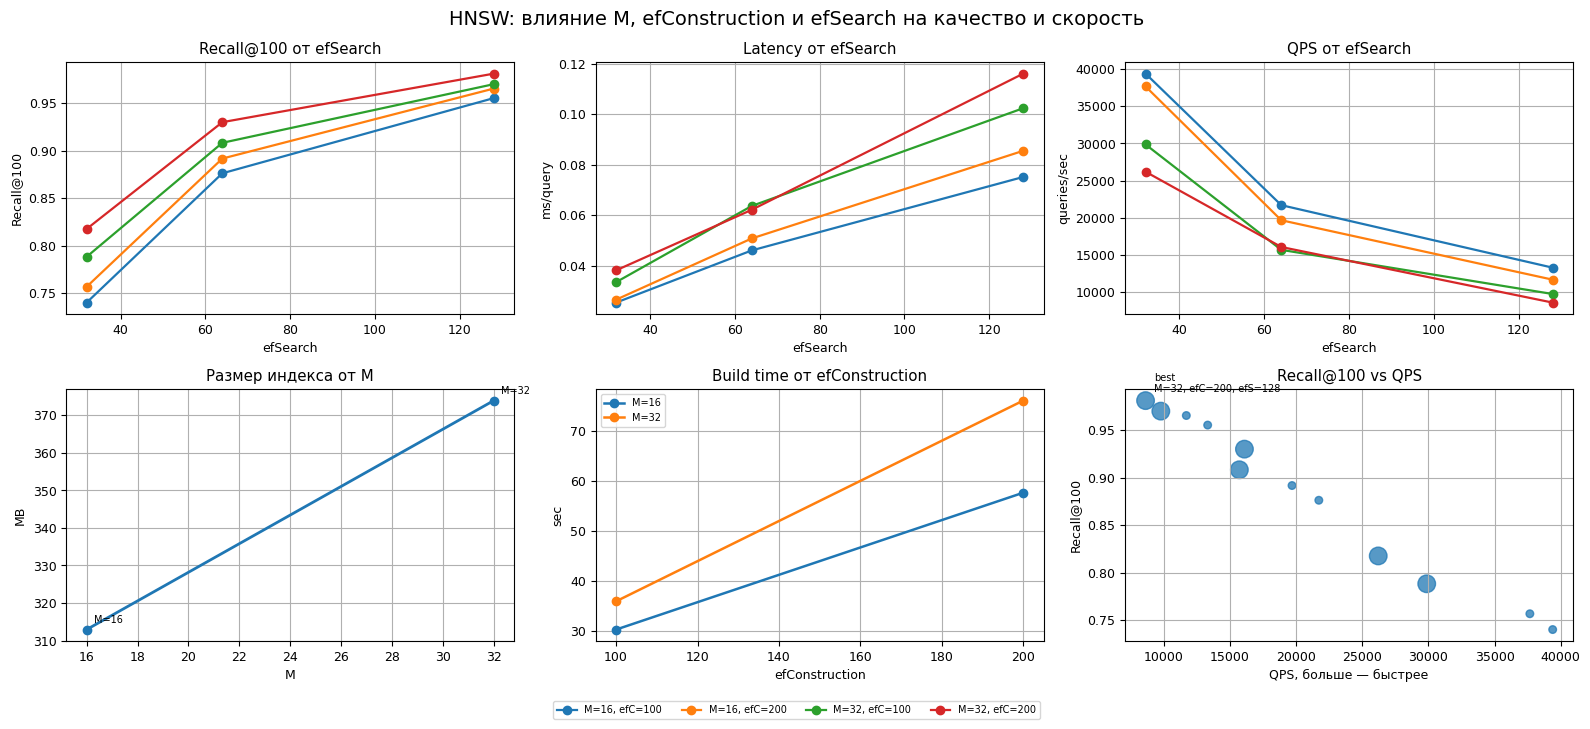

In [60]:
hnsw_plot_df = hnsw_results_df.copy()

hnsw_plot_df["config"] = (
    "M=" + hnsw_plot_df["M"].astype(str) +
    ", efC=" + hnsw_plot_df["efConstruction"].astype(str)
)

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
axes = axes.flatten()

# 1. Recall от efSearch
for config, group in hnsw_plot_df.groupby("config"):
    group = group.sort_values("efSearch")

    axes[0].plot(
        group["efSearch"],
        group["recall@100"],
        marker="o",
        linewidth=1.6,
        label=config
    )

axes[0].set_title("Recall@100 от efSearch")
axes[0].set_xlabel("efSearch")
axes[0].set_ylabel("Recall@100")


# 2. Время одного запроса от efSearch
for config, group in hnsw_plot_df.groupby("config"):
    group = group.sort_values("efSearch")

    axes[1].plot(
        group["efSearch"],
        group["ms_per_query"],
        marker="o",
        linewidth=1.6
    )

axes[1].set_title("Latency от efSearch")
axes[1].set_xlabel("efSearch")
axes[1].set_ylabel("ms/query")


# 3. QPS от efSearch
for config, group in hnsw_plot_df.groupby("config"):
    group = group.sort_values("efSearch")

    axes[2].plot(
        group["efSearch"],
        group["qps"],
        marker="o",
        linewidth=1.6
    )

axes[2].set_title("QPS от efSearch")
axes[2].set_xlabel("efSearch")
axes[2].set_ylabel("queries/sec")


# 4. Размер индекса от M
# efSearch не влияет на размер индекса, поэтому усредняем по efSearch и efConstruction
hnsw_size_df = (
    hnsw_plot_df
    .groupby("M", as_index=False)["index_size_mb"]
    .mean()
    .sort_values("M")
)

axes[3].plot(
    hnsw_size_df["M"],
    hnsw_size_df["index_size_mb"],
    marker="o",
    linewidth=2
)

for _, row in hnsw_size_df.iterrows():
    axes[3].annotate(
        f"M={int(row['M'])}",
        (row["M"], row["index_size_mb"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=7
    )

axes[3].set_title("Размер индекса от M")
axes[3].set_xlabel("M")
axes[3].set_ylabel("MB")


# 5. Build time от efConstruction для разных M
# efSearch не влияет на построение индекса, поэтому усредняем по efSearch
hnsw_build_df = (
    hnsw_plot_df
    .groupby(["M", "efConstruction"], as_index=False)["build_time_sec"]
    .mean()
    .sort_values(["M", "efConstruction"])
)

for m, group in hnsw_build_df.groupby("M"):
    group = group.sort_values("efConstruction")

    axes[4].plot(
        group["efConstruction"],
        group["build_time_sec"],
        marker="o",
        linewidth=1.8,
        label=f"M={m}"
    )

axes[4].set_title("Build time от efConstruction")
axes[4].set_xlabel("efConstruction")
axes[4].set_ylabel("sec")
axes[4].legend(fontsize=7)


# 6. Recall vs QPS
# Это главный trade-off: выше — качественнее, правее — быстрее
sizes = normalize_sizes(hnsw_plot_df["index_size_mb"])

axes[5].scatter(
    hnsw_plot_df["qps"],
    hnsw_plot_df["recall@100"],
    s=sizes,
    alpha=0.75
)

# Лучшая конфигурация по recall, при равенстве — с большим QPS
best = (
    hnsw_plot_df
    .sort_values(["recall@100", "qps"], ascending=[False, False])
    .iloc[0]
)

axes[5].annotate(
    f"best\nM={best['M']}, efC={best['efConstruction']}, efS={best['efSearch']}",
    (best["qps"], best["recall@100"]),
    textcoords="offset points",
    xytext=(6, 6),
    fontsize=7
)

axes[5].set_title("Recall@100 vs QPS")
axes[5].set_xlabel("QPS, больше — быстрее")
axes[5].set_ylabel("Recall@100")


# Общая легенда для графиков с конфигурациями
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    fontsize=7,
    bbox_to_anchor=(0.5, -0.04)
)

fig.suptitle(
    "HNSW: влияние M, efConstruction и efSearch на качество и скорость",
    fontsize=14
)

plt.tight_layout()
plt.show()

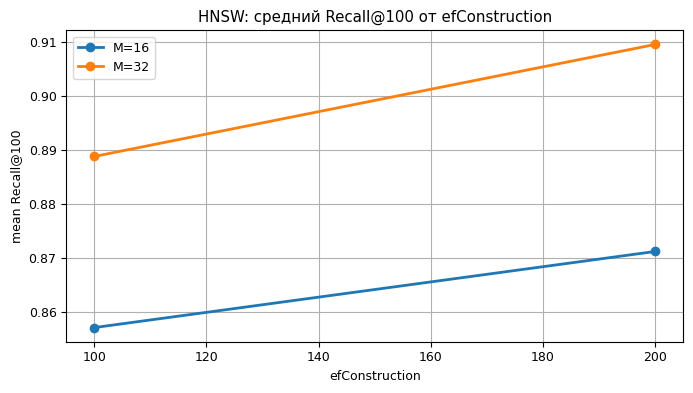

In [61]:
hnsw_recall_efc_df = (
    hnsw_plot_df
    .groupby(["M", "efConstruction"], as_index=False)["recall@100"]
    .mean()
    .sort_values(["M", "efConstruction"])
)

fig, ax = plt.subplots(figsize=(7, 4))

for m, group in hnsw_recall_efc_df.groupby("M"):
    group = group.sort_values("efConstruction")

    ax.plot(
        group["efConstruction"],
        group["recall@100"],
        marker="o",
        linewidth=2,
        label=f"M={m}"
    )

ax.set_title("HNSW: средний Recall@100 от efConstruction")
ax.set_xlabel("efConstruction")
ax.set_ylabel("mean Recall@100")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

при увеличении `efSearch` растет полнота поиска `Recall@100`, но одновременно увеличивается время поиска `ms_per_query`, а `QPS` снижается. - алгоритм держит больше кандидатов во время поиска и исследует граф шире, поэтому находит более точных соседей, но тратит больше времени.

`M` сильно влияет на качество и размер индекса. При увеличении M Встроенный код граф становится более связным, за счет этого recall@100 растет, но и растут затраты на память

Чем выше `efConstruction`, тем дольше строится индекс, потому что при вставке каждого вектора рассматривается больше кандидатов для выбора соседей. При этом прирост качества не всегда линейный. (Для M=32 увеличение с 50 до 200 почти не улучишло recall@100, но увеличило время построения примерно в 2.5 раза)

При маленьком `efSearch=16` качество резко падает даже при большом `M`.
Самый быстрый поиск получился при малых значениях `M` и `efSearch`, например:

```text
M=8, efConstruction=100, efSearch=16:
qps = 14272.75, ms_per_query = 0.070064, recall@100 = 0.492881
```

Но такая конфигурация дает слишком низкий recall, поэтому она подходит только для сценариев, где скорость намного важнее качества.

В итоге **оптимальные параметры HNSW** `M=32, efConstruction=100, efSearch=128`(пости максимальный recall при этом нет больших затракт на построение индекса)


### **5.3 IVF+PQ**

В эксперименте исследуются параметры

- **nlist** — количество кластеров IVF
- **m** — количество подпространств для квантования (на сколько частей делим вектор)
- **nbits** — количество бит для кодирования каждй части вектора 
- **nprobe** — количество кластеров, просматриваемых при поиске

In [36]:
# Старые параметры:
# ivfpq_nlist_values = [100, 256, 512]
# ivfpq_m_values = [8, 16]
# ivfpq_nbits_values = [8]
# ivfpq_nprobe_values = [1, 4, 8, 16, 32, 64]

# Расширенные параметры для улучшения качества IVF+PQ
ivfpq_nlist_values = [100, 256, 512, 1024, 2048]
ivfpq_m_values = [16, 32, 64]
ivfpq_nbits_values = [8]
ivfpq_nprobe_values = [32, 64, 128, 256]

ivfpq_results = []

for nlist in ivfpq_nlist_values:
    for m in ivfpq_m_values:
        for nbits in ivfpq_nbits_values:

            if dim % m != 0:
                print(f"Skip IVF+PQ | m={m}, потому что dim={dim} не делится на m")
                continue

            quantizer = faiss.IndexFlatL2(dim)

            index_ivfpq = faiss.IndexIVFPQ(
                quantizer,
                dim,
                nlist,
                m,
                nbits
            )

            t0 = time.perf_counter()
            index_ivfpq.train(search_vectors)
            index_ivfpq.add(search_vectors)
            build_time_sec = time.perf_counter() - t0

            index_size_mb = get_index_size_mb(index_ivfpq)

            for nprobe in ivfpq_nprobe_values:
                index_ivfpq.nprobe = nprobe

                t0 = time.perf_counter()
                _, predicted_neighbors = index_ivfpq.search(query_vectors, TOP_K)
                search_time_sec = time.perf_counter() - t0

                recall = recall_at_k(
                    predicted_neighbors=predicted_neighbors,
                    true_neighbors=ground_truth,
                    k=TOP_K
                )

                row = save_result(
                    results=results,
                    algorithm="IVF+PQ",
                    params=f"nlist={nlist}, m={m}, nbits={nbits}, nprobe={nprobe}",
                    build_time_sec=build_time_sec,
                    search_time_sec=search_time_sec,
                    recall=recall,
                    index_size_mb=index_size_mb,
                    extra_params={
                        "nlist": nlist,
                        "m": m,
                        "nbits": nbits,
                        "nprobe": nprobe
                    }
                )

                ivfpq_results.append(row)

                del predicted_neighbors
                gc.collect()

            del index_ivfpq, quantizer
            gc.collect()

In [43]:
ivfpq_results_df = pd.DataFrame(ivfpq_results)

ivfpq_results_df = ivfpq_results_df.sort_values(
    by=["recall@100", "qps"],
    ascending=[False, False]
).reset_index(drop=True)

ivfpq_results_df.head()

,algorithm,params,build_time_sec,search_time_sec,qps,ms_per_query,recall@100,index_size_mb,nlist,m,nbits,nprobe
0,IVF+PQ,"nlist=2048, m=64, nbits=8, nprobe=256",63.443719,7.278302,1373.946854,0.727830,0.917559,35.473072,2048,64,8,256
1,IVF+PQ,"nlist=1024, m=64, nbits=8, nprobe=256",52.503337,8.716270,1147.279769,0.871627,0.915264,34.965260,1024,64,8,256
2,IVF+PQ,"nlist=1024, m=64, nbits=8, nprobe=128",52.503337,4.429405,2257.639825,0.442940,0.914705,34.965260,1024,64,8,128
3,IVF+PQ,"nlist=2048, m=64, nbits=8, nprobe=128",63.443719,3.678302,2718.646092,0.367830,0.914528,35.473072,2048,64,8,128
4,IVF+PQ,"nlist=512, m=64, nbits=8, nprobe=256",49.426136,13.422057,745.042273,1.342206,0.913431,34.711353,512,64,8,256


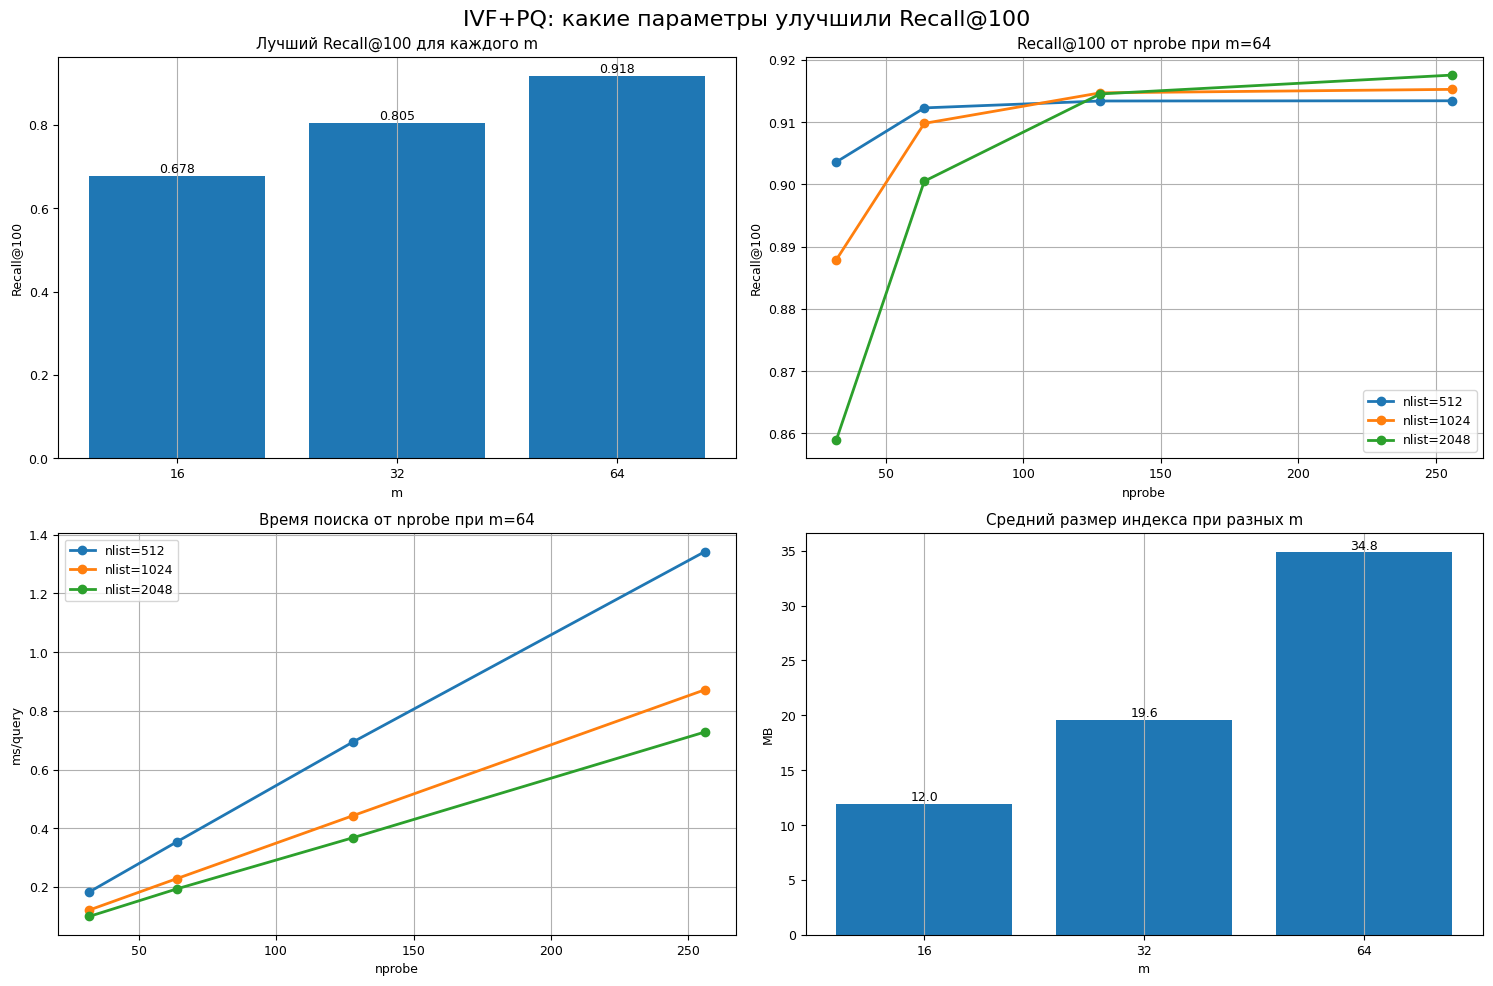

In [49]:
ivfpq_plot_df = ivfpq_results_df.copy()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# -----------------------------
# 1. Лучший recall для каждого m
# -----------------------------
best_by_m = (
    ivfpq_plot_df
    .sort_values("recall@100", ascending=False)
    .groupby("m", as_index=False)
    .first()
    .sort_values("m")
)

axes[0, 0].bar(
    best_by_m["m"].astype(str),
    best_by_m["recall@100"]
)

axes[0, 0].set_title("Лучший Recall@100 для каждого m")
axes[0, 0].set_xlabel("m")
axes[0, 0].set_ylabel("Recall@100")
axes[0, 0].grid(axis="y")

for _, row in best_by_m.iterrows():
    axes[0, 0].text(
        str(int(row["m"])),
        row["recall@100"],
        f"{row['recall@100']:.3f}",
        ha="center",
        va="bottom"
    )

# -----------------------------
# 2. Recall от nprobe для m=64
# -----------------------------
df_m64 = ivfpq_plot_df[
    (ivfpq_plot_df["m"] == 64) &
    (ivfpq_plot_df["nlist"].isin([512, 1024, 2048]))
].copy()

for nlist, group in df_m64.groupby("nlist"):
    group = group.sort_values("nprobe")
    axes[0, 1].plot(
        group["nprobe"],
        group["recall@100"],
        marker="o",
        linewidth=2,
        label=f"nlist={nlist}"
    )

axes[0, 1].set_title("Recall@100 от nprobe при m=64")
axes[0, 1].set_xlabel("nprobe")
axes[0, 1].set_ylabel("Recall@100")
axes[0, 1].grid(True)
axes[0, 1].legend()

# -----------------------------
# 3. ms/query от nprobe для m=64
# -----------------------------
for nlist, group in df_m64.groupby("nlist"):
    group = group.sort_values("nprobe")
    axes[1, 0].plot(
        group["nprobe"],
        group["ms_per_query"],
        marker="o",
        linewidth=2,
        label=f"nlist={nlist}"
    )

axes[1, 0].set_title("Время поиска от nprobe при m=64")
axes[1, 0].set_xlabel("nprobe")
axes[1, 0].set_ylabel("ms/query")
axes[1, 0].grid(True)
axes[1, 0].legend()

# -----------------------------
# 4. Размер индекса от m
# -----------------------------
size_by_m = (
    ivfpq_plot_df
    .groupby("m", as_index=False)["index_size_mb"]
    .mean()
    .sort_values("m")
)

axes[1, 1].bar(
    size_by_m["m"].astype(str),
    size_by_m["index_size_mb"]
)

axes[1, 1].set_title("Средний размер индекса при разных m")
axes[1, 1].set_xlabel("m")
axes[1, 1].set_ylabel("MB")
axes[1, 1].grid(axis="y")

for _, row in size_by_m.iterrows():
    axes[1, 1].text(
        str(int(row["m"])),
        row["index_size_mb"],
        f"{row['index_size_mb']:.1f}",
        ha="center",
        va="bottom"
    )

fig.suptitle(
    "IVF+PQ: какие параметры улучшили Recall@100",
    fontsize=16
)

plt.tight_layout()
plt.show()

После новых замеров 

Главное улучшение Recall@100 дало увеличение параметра m. При увеличении m вектор делится на большее число подвекторов, поэтому квантование получается точнее. После расширения эксперимента и добавления m=64 качество заметно выросло: для m=16 recall был примерно 0.65–0.68, для m=32 — около 0.79–0.81, а для m=64 recall поднялся до 0.91–0.92. 

Также помогло увеличение nprobe. При больших значениях nprobe индекс просматривает больше кластеров, поэтому чаще находит настоящих ближайших соседей. Например, при nlist=2048, m=64 переход от nprobe=32 к nprobe=128/256 поднял Recall@100 примерно с 0.859 до 0.915–0.918.

Увеличение nlist помогло, но не так однозначно. Лучший recall получился при большом числе кластеров nlist=2048. Однако также требуется и высокий nprobe, потому что возможны случаи, что часть ближайших соседей окажется в непросмотренных кластерах.

Лучший Recall@100 даёт конфигурация nlist=2048, m=64, nbits=8, nprobe=256: качество достигает примерно 0.918, но поиск заметно медленнее, чем у вариантов с меньшим nprobe.

В итоге оптимальные параметры IVF+PQ — nlist=1024, m=64, nbits=8, nprobe=128, потому что эта конфигурация даёт почти максимальный Recall@100 ≈ 0.915, но ищет почти в 2 раза быстрее, чем вариант с nprobe=256. 

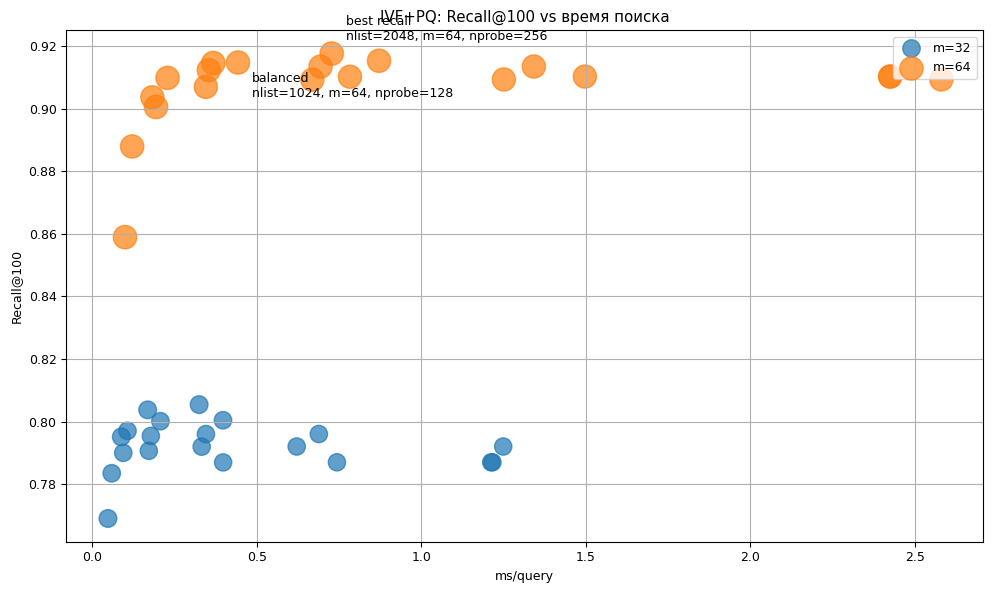

In [50]:
ivfpq_plot_df = ivfpq_results_df.copy()

# убираем m=16 как слишком низкое качество
# оставляем m=32 и m=64
tradeoff_df = ivfpq_plot_df[
    ivfpq_plot_df["m"].isin([32, 64])
].copy()

fig, ax = plt.subplots(figsize=(10, 6))

for m, group in tradeoff_df.groupby("m"):
    ax.scatter(
        group["ms_per_query"],
        group["recall@100"],
        s=group["index_size_mb"] * 8,
        alpha=0.7,
        label=f"m={m}"
    )

# Отмечаем лучший recall
best_recall = tradeoff_df.loc[tradeoff_df["recall@100"].idxmax()]

ax.annotate(
    f"best recall\nnlist={int(best_recall['nlist'])}, "
    f"m={int(best_recall['m'])}, "
    f"nprobe={int(best_recall['nprobe'])}",
    (best_recall["ms_per_query"], best_recall["recall@100"]),
    textcoords="offset points",
    xytext=(10, 10),
    fontsize=9
)

# Отмечаем хороший компромисс
balanced = tradeoff_df[
    (tradeoff_df["nlist"] == 1024) &
    (tradeoff_df["m"] == 64) &
    (tradeoff_df["nprobe"] == 128)
].iloc[0]

ax.annotate(
    "balanced\nnlist=1024, m=64, nprobe=128",
    (balanced["ms_per_query"], balanced["recall@100"]),
    textcoords="offset points",
    xytext=(10, -25),
    fontsize=9
)

ax.set_title("IVF+PQ: Recall@100 vs время поиска")
ax.set_xlabel("ms/query")
ax.set_ylabel("Recall@100")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

 прошлые выводы

при увеличении `nprobe` растет `Recall@100`, но одновременно увеличивается время поиска `ms_per_query`, а `QPS` падает. (чем больше кластеров проверяется, тем выше шанс найти настоящих ближайших соседей, но тем больше кандидатов нужно обработать)

прирост качества происходит при переходе от очень маленьких значений `nprobe` к средним. После nprobe=32 прирост recall становится почти незаметным.

Параметр `m` сильно влияет на качество PQ-сжатия(квантование получается точнее) Из-за этого recall заметно выше, но индекс занимает больше места.

увеличение `nlist` до 512 одновременно улучшило скорость и немного повысило recall. Однако при слишком маленьком nprobe = 1 большой nlist может ухудшать полноту (ближайшие соседи попали в соседние кластеры)

Самый быстрый вариант — nlist=512, m=16, nbits=8, но качество слишком низкое, поэтому эта конфигурация подходит только для сценариев, где важна максимальная скорость, а точность почти не критична.

Лучший recall дает конфигурация — nlist=512, m=16, nbits=8, nprobe=64, но она заметно медленнее варианта с nprobe=32, при этом прирост полноты очень маленький.

В итоге **оптимальные параметры IVF+PQ** — nlist=512, m=16, nbits=8, nprobe=32, так как эта конфигурация дает почти максимальный Recall@100 = 0.676824, но ищет почти в 1.8 раза быстрее, чем вариант с nprobe=64


### **Общие результаты**

In [44]:
#лучшие конфигурации каждого алгоритма по Recall@100
all_results_df = pd.DataFrame(results).copy()

best_by_recall = (
    all_results_df
    .sort_values(
        ["algorithm", "recall@100", "qps"],
        ascending=[True, False, False]
    )
    .groupby("algorithm", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

best_by_recall[
    [
        "algorithm",
        "params",
        "recall@100",
        "qps",
        "ms_per_query",
        "build_time_sec",
        "search_time_sec",
        "index_size_mb"
    ]
]

,algorithm,params,recall@100,qps,ms_per_query,build_time_sec,search_time_sec,index_size_mb
0,HNSW,"M=32, efConstruction=200, efSearch=128",0.981059,9558.047360,0.104624,66.334429,1.046239,373.903292
1,IVF+PQ,"nlist=2048, m=64, nbits=8, nprobe=256",0.917559,1373.946854,0.727830,63.443719,7.278302,35.473072
2,LSH,nbits=2048,0.715765,954.592306,1.047568,1.237108,10.475676,123.070401


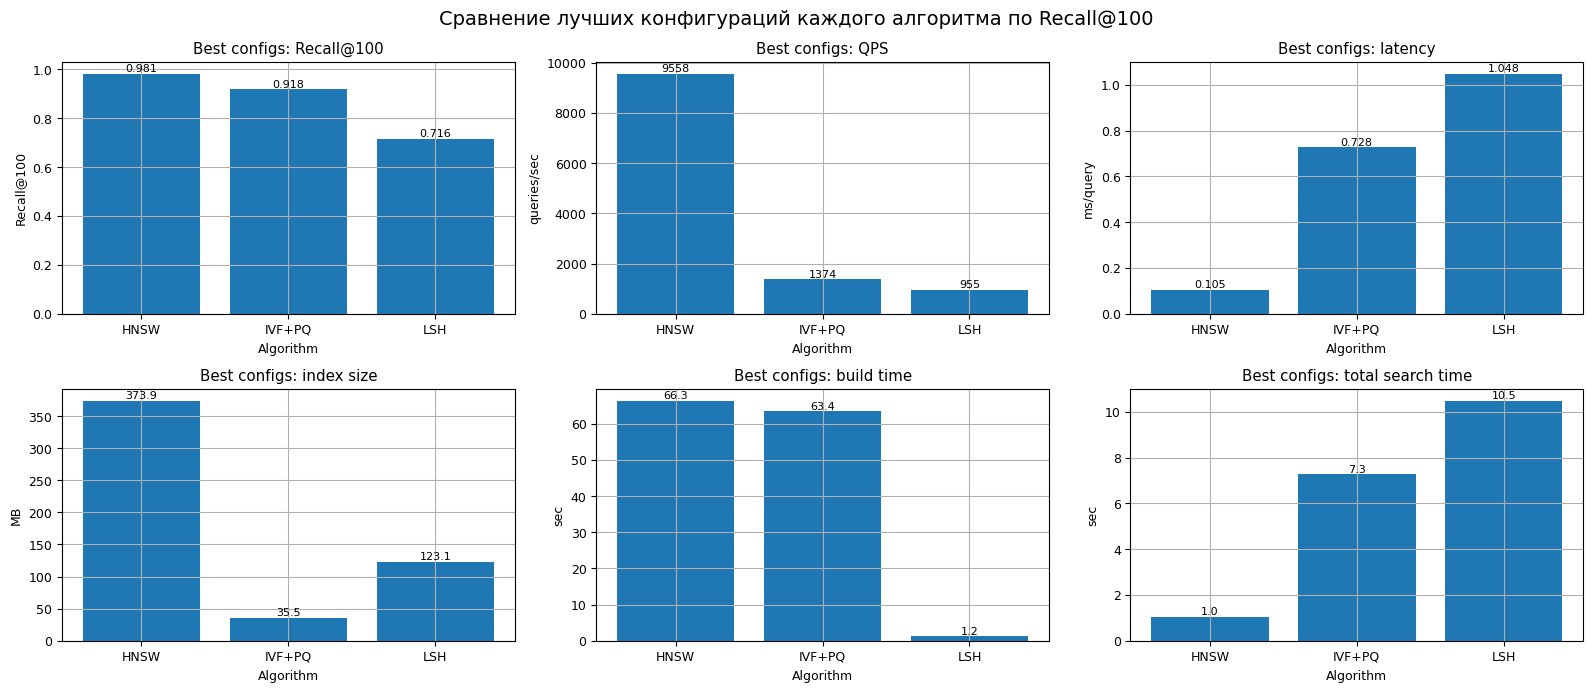

In [47]:
fig, axes = plt.subplots(2, 3, figsize=(16, 7))
axes = axes.flatten()

plot_df = best_by_recall.sort_values("recall@100", ascending=False)

# 1. Recall@100
axes[0].bar(plot_df["algorithm"], plot_df["recall@100"])
axes[0].set_title("Best configs: Recall@100")
axes[0].set_xlabel("Algorithm")
axes[0].set_ylabel("Recall@100")

for _, row in plot_df.iterrows():
    axes[0].text(
        row["algorithm"],
        row["recall@100"],
        f"{row['recall@100']:.3f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

# 2. QPS
axes[1].bar(plot_df["algorithm"], plot_df["qps"])
axes[1].set_title("Best configs: QPS")
axes[1].set_xlabel("Algorithm")
axes[1].set_ylabel("queries/sec")

for _, row in plot_df.iterrows():
    axes[1].text(
        row["algorithm"],
        row["qps"],
        f"{row['qps']:.0f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

# 3. ms_per_query
axes[2].bar(plot_df["algorithm"], plot_df["ms_per_query"])
axes[2].set_title("Best configs: latency")
axes[2].set_xlabel("Algorithm")
axes[2].set_ylabel("ms/query")

for _, row in plot_df.iterrows():
    axes[2].text(
        row["algorithm"],
        row["ms_per_query"],
        f"{row['ms_per_query']:.3f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

# 4. index_size_mb
axes[3].bar(plot_df["algorithm"], plot_df["index_size_mb"])
axes[3].set_title("Best configs: index size")
axes[3].set_xlabel("Algorithm")
axes[3].set_ylabel("MB")

for _, row in plot_df.iterrows():
    axes[3].text(
        row["algorithm"],
        row["index_size_mb"],
        f"{row['index_size_mb']:.1f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

# 5. build_time_sec
axes[4].bar(plot_df["algorithm"], plot_df["build_time_sec"])
axes[4].set_title("Best configs: build time")
axes[4].set_xlabel("Algorithm")
axes[4].set_ylabel("sec")

for _, row in plot_df.iterrows():
    axes[4].text(
        row["algorithm"],
        row["build_time_sec"],
        f"{row['build_time_sec']:.1f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

# 6. search_time_sec
axes[5].bar(plot_df["algorithm"], plot_df["search_time_sec"])
axes[5].set_title("Best configs: total search time")
axes[5].set_xlabel("Algorithm")
axes[5].set_ylabel("sec")

for _, row in plot_df.iterrows():
    axes[5].text(
        row["algorithm"],
        row["search_time_sec"],
        f"{row['search_time_sec']:.1f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

fig.suptitle(
    "Сравнение лучших конфигураций каждого алгоритма по Recall@100",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [77]:
# выбранные конфигурации:
# IVF+PQ — 2-й вариант по Recall@100
# HNSW   — 2-й вариант по Recall@100
# LSH    — лучший вариант по Recall@100

all_results_df = pd.DataFrame(results).copy()

ranked_configs = (
    all_results_df
    .sort_values(
        ["algorithm", "recall@100"],
        ascending=[True, False]
    )
    .copy()
)

ranked_configs["recall_rank"] = (
    ranked_configs
    .groupby("algorithm")
    .cumcount() + 1
)

selected_configs = pd.concat([
    # IVF+PQ — второй вариант
    ranked_configs[
        (ranked_configs["algorithm"] == "IVF+PQ") &
        (ranked_configs["recall_rank"] == 2)
    ],

    # HNSW — второй вариант
    ranked_configs[
        (ranked_configs["algorithm"] == "HNSW") &
        (ranked_configs["recall_rank"] == 3)
    ],

    # LSH — лучший вариант
    ranked_configs[
        (ranked_configs["algorithm"] == "LSH") &
        (ranked_configs["recall_rank"] == 1)
    ]
], ignore_index=True)

selected_configs[
    [
        "algorithm",
        "params",
        "recall_rank",
        "recall@100",
        "qps",
        "ms_per_query",
        "build_time_sec",
        "search_time_sec",
        "index_size_mb"
    ]
]

,algorithm,params,recall_rank,recall@100,qps,ms_per_query,build_time_sec,search_time_sec,index_size_mb
0,IVF+PQ,"nlist=1024, m=64, nbits=8, nprobe=256",2,0.915264,1147.279769,0.871627,52.503337,8.716270,34.965260
1,HNSW,"M=32, efConstruction=100, efSearch=128",3,0.970021,9769.553811,0.102359,35.865113,1.023588,373.903292
2,LSH,nbits=2048,1,0.715765,954.592306,1.047568,1.237108,10.475676,123.070401


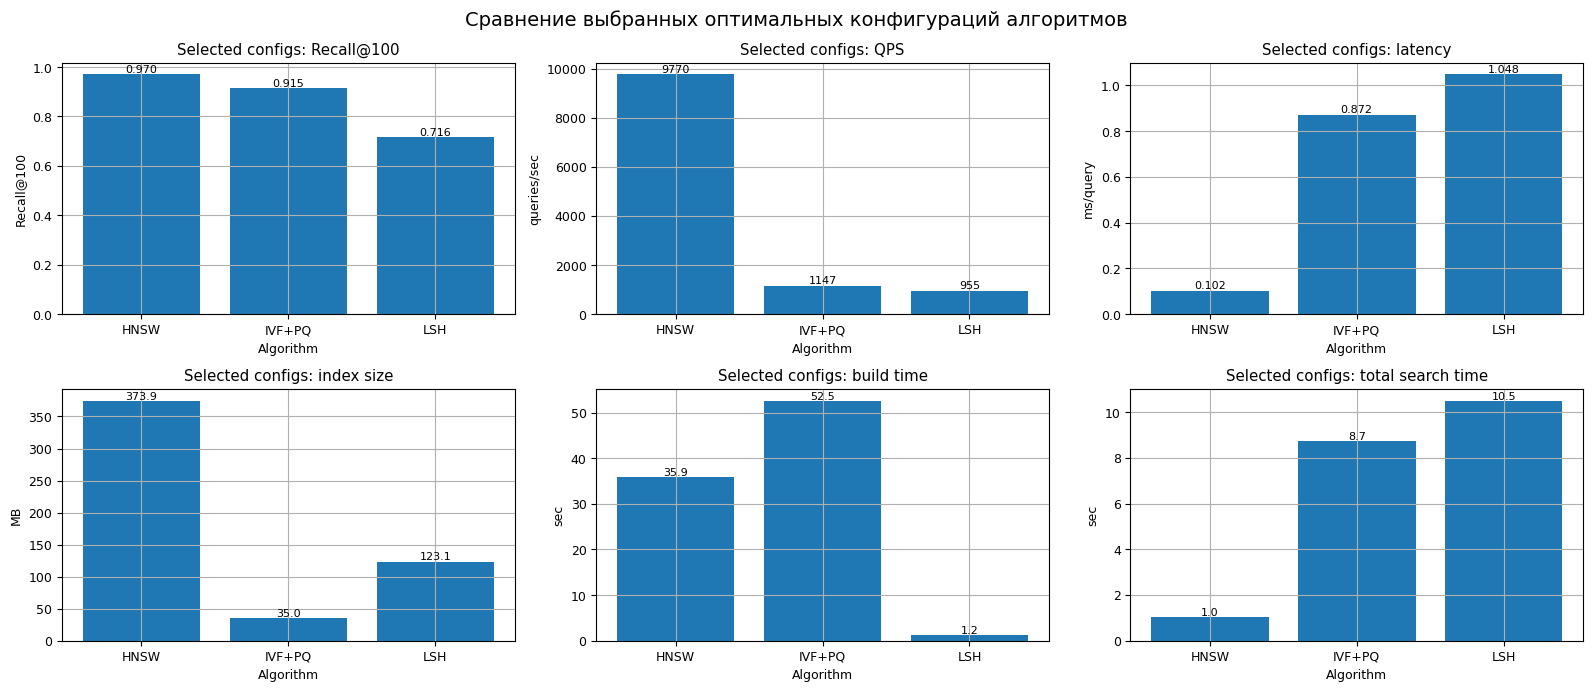

In [78]:
fig, axes = plt.subplots(2, 3, figsize=(16, 7))
axes = axes.flatten()

plot_df = selected_configs.sort_values("recall@100", ascending=False)

# 1. Recall@100
axes[0].bar(plot_df["algorithm"], plot_df["recall@100"])
axes[0].set_title("Selected configs: Recall@100")
axes[0].set_xlabel("Algorithm")
axes[0].set_ylabel("Recall@100")

for _, row in plot_df.iterrows():
    axes[0].text(
        row["algorithm"],
        row["recall@100"],
        f"{row['recall@100']:.3f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

# 2. QPS
axes[1].bar(plot_df["algorithm"], plot_df["qps"])
axes[1].set_title("Selected configs: QPS")
axes[1].set_xlabel("Algorithm")
axes[1].set_ylabel("queries/sec")

for _, row in plot_df.iterrows():
    axes[1].text(
        row["algorithm"],
        row["qps"],
        f"{row['qps']:.0f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

# 3. ms_per_query
axes[2].bar(plot_df["algorithm"], plot_df["ms_per_query"])
axes[2].set_title("Selected configs: latency")
axes[2].set_xlabel("Algorithm")
axes[2].set_ylabel("ms/query")

for _, row in plot_df.iterrows():
    axes[2].text(
        row["algorithm"],
        row["ms_per_query"],
        f"{row['ms_per_query']:.3f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

# 4. index_size_mb
axes[3].bar(plot_df["algorithm"], plot_df["index_size_mb"])
axes[3].set_title("Selected configs: index size")
axes[3].set_xlabel("Algorithm")
axes[3].set_ylabel("MB")

for _, row in plot_df.iterrows():
    axes[3].text(
        row["algorithm"],
        row["index_size_mb"],
        f"{row['index_size_mb']:.1f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

# 5. build_time_sec
axes[4].bar(plot_df["algorithm"], plot_df["build_time_sec"])
axes[4].set_title("Selected configs: build time")
axes[4].set_xlabel("Algorithm")
axes[4].set_ylabel("sec")

for _, row in plot_df.iterrows():
    axes[4].text(
        row["algorithm"],
        row["build_time_sec"],
        f"{row['build_time_sec']:.1f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

# 6. search_time_sec
axes[5].bar(plot_df["algorithm"], plot_df["search_time_sec"])
axes[5].set_title("Selected configs: total search time")
axes[5].set_xlabel("Algorithm")
axes[5].set_ylabel("sec")

for _, row in plot_df.iterrows():
    axes[5].text(
        row["algorithm"],
        row["search_time_sec"],
        f"{row['search_time_sec']:.1f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

fig.suptitle(
    "Сравнение выбранных оптимальных конфигураций алгоритмов",
    fontsize=14
)

plt.tight_layout()
plt.show()

### Recall@100 vs QPS

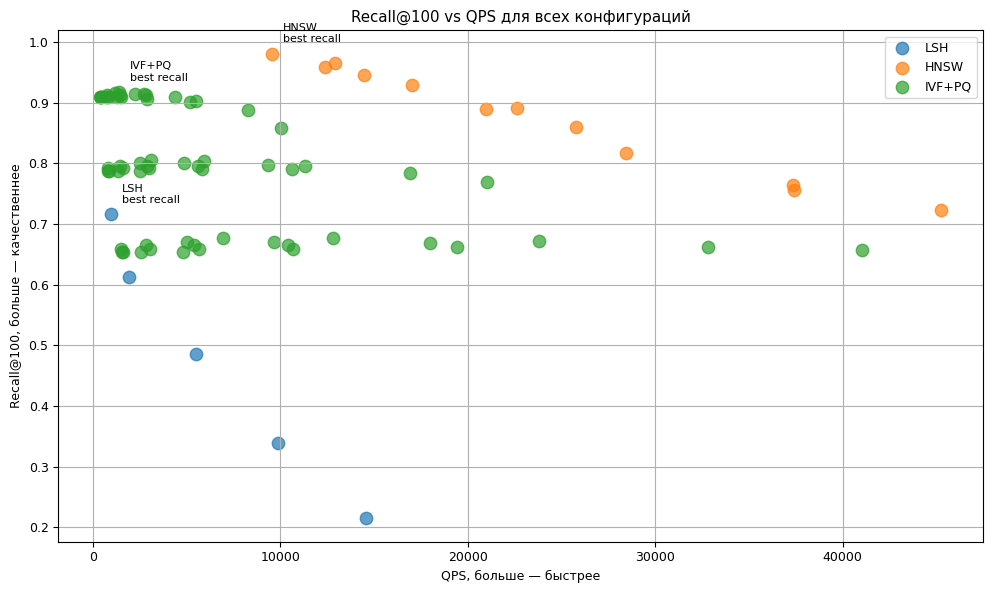

In [41]:
fig, ax = plt.subplots(figsize=(10, 6))

algorithms = all_results_df["algorithm"].unique()

for algorithm in algorithms:
    group = all_results_df[all_results_df["algorithm"] == algorithm]

    ax.scatter(
        group["qps"],
        group["recall@100"],
        s=80,
        alpha=0.7,
        label=algorithm
    )

for _, row in best_by_recall.iterrows():
    ax.annotate(
        f"{row['algorithm']}\nbest recall",
        (row["qps"], row["recall@100"]),
        textcoords="offset points",
        xytext=(8, 8),
        fontsize=8
    )

ax.set_title("Recall@100 vs QPS для всех конфигураций")
ax.set_xlabel("QPS, больше — быстрее")
ax.set_ylabel("Recall@100, больше — качественнее")
ax.legend()

plt.tight_layout()
plt.show()